# Dia 1 — Introdução ao Pandas

## Verificando a instalação

Antes de começar, confirmamos que o Pandas está instalado corretamente e verificamos sua versão.

In [1]:
import pandas as pd
print(pd.__version__)

3.0.3


## Criando primeiro DataFrame

Um DataFrame é uma tabela com linhas e colunas, similar ao Excel.
Aqui criamos um dataset fictício de uma joalheria com 4 produtos.

In [2]:
import pandas as pd

dados = {
    "produto" : ["Anel", "Colar", "Brinco", "Pulseira"],
    "metal" : ["Ouro 18k", "Prata", "Ouro 18k", "Prata"],
    "preco" : [1200, 450, 890, 320],
    "estoque" : [5, 12, 3, 8]
}

df = pd.DataFrame(dados)
df

,produto,metal,preco,estoque
0,Anel,Ouro 18k,1200,5
1,Colar,Prata,450,12
2,Brinco,Ouro 18k,890,3
3,Pulseira,Prata,320,8


## Explorando o DataFrame

### Shape — Dimensões da tabela

Retorna uma tupla (linhas, colunas). Útil para entender o tamanho do dataset rapidamente.

In [3]:
df.shape

(4, 4)

### Info — Raio-x do DataFrame

Mostra o tipo de dado de cada coluna (str, int64, float64) e se há valores nulos.
Essencial para entender a estrutura dos dados antes de qualquer análise.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   produto  4 non-null      str  
 1   metal    4 non-null      str  
 2   preco    4 non-null      int64
 3   estoque  4 non-null      int64
dtypes: int64(2), str(2)
memory usage: 309.0 bytes


### Describe — Estatísticas automáticas

Gera um resumo estatístico das colunas numéricas: média, desvio padrão, mínimo, máximo e quartis.
Permite entender a distribuição dos dados com um único comando.

In [5]:
df.describe()

,preco,estoque
count,4.000000,4.00000
mean,715.000000,7.00000
std,405.010288,3.91578
min,320.000000,3.00000
25%,417.500000,4.50000
50%,670.000000,6.50000
75%,967.500000,9.00000
max,1200.000000,12.00000


## Selecionando dados

### Selecionando uma coluna

Usar `df["nome_da_coluna"]` retorna uma Series — a estrutura de uma única coluna do Pandas.

In [6]:
df["preco"]

0    1200
1     450
2     890
3     320
Name: preco, dtype: int64

### Filtrando linhas por condição

O padrão `df[df["coluna"] == "valor"]` filtra apenas as linhas que atendem à condição.
Aqui filtramos apenas os produtos de Ouro 18k.

In [7]:
df[df["metal"] == "Ouro 18k"]

,produto,metal,preco,estoque
0,Anel,Ouro 18k,1200,5
2,Brinco,Ouro 18k,890,3


## Análises agrupadas

### Groupby — Agrupando por categoria

`groupby()` agrupa os dados por uma coluna e aplica uma função (aqui, a média de preço).
Resultado: preço médio por tipo de metal.

In [8]:
df.groupby("metal")["preco"].mean()

metal
Ouro 18k    1045.0
Prata        385.0
Name: preco, dtype: float64

### Encontrando o valor máximo

Combinamos `df["preco"].max()` com um filtro para retornar a linha completa
do produto mais caro do estoque.

In [9]:
df[df["preco"] == df["preco"].max()]

,produto,metal,preco,estoque
0,Anel,Ouro 18k,1200,5


## Criando novas colunas

Podemos criar colunas calculadas a partir de colunas existentes.
Aqui multiplicamos preço × estoque para obter o valor total em estoque por produto.

In [10]:
df["valor_total"] = df["preco"] * df["estoque"]
df

,produto,metal,preco,estoque,valor_total
0,Anel,Ouro 18k,1200,5,6000
1,Colar,Prata,450,12,5400
2,Brinco,Ouro 18k,890,3,2670
3,Pulseira,Prata,320,8,2560


## Visualização de dados

### Gráfico de barras — Valor total em estoque

Usamos matplotlib para visualizar os dados. As cores foram escolhidas
tematicamente: dourado para Ouro 18k e cinza para Prata.

Matplotlib is building the font cache; this may take a moment.


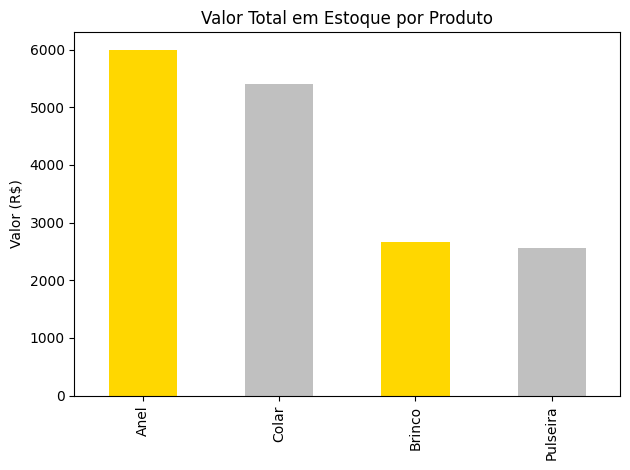

In [11]:
import matplotlib.pyplot as plt

df.plot(
    kind="bar",
    x="produto",
    y="valor_total",
    color=["gold", "silver", "gold", "silver"],
    legend=False,
    title="Valor Total em Estoque por Produto"
)

plt.ylabel("Valor (R$)")
plt.xlabel("")
plt.tight_layout()
plt.show()